In [13]:
# ============================================================================
# IMPORTS
# ============================================================================
import os
import sys
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.utils.class_weight import compute_class_weight

# Add path for data loader
sys.path.append(os.path.abspath('..'))
from src.data_loader import SP500DataLoader

# ============================================================================
# REPRODUCIBILITY - SET ONCE, AT THE VERY TOP
# ============================================================================
SEED = 42  # Use the same seed throughout

# 1. Python's random module
random.seed(SEED)

# 2. NumPy
np.random.seed(SEED)

# 3. TensorFlow
tf.random.set_seed(SEED)

# 4. Environment variable for Python's hash randomization
os.environ['PYTHONHASHSEED'] = str(SEED)

# 5. CRITICAL: Disable GPU nondeterminism
os.environ['TF_DETERMINISTIC_OPS'] = '1'

# 6. Enable TensorFlow determinism
tf.config.experimental.enable_op_determinism()

print("="*70)
print("LSTM VOLATILITY PREDICTION WITH MONTE CARLO STRESS TESTING")
print(f"Random Seed: {SEED}")
print("="*70)

LSTM VOLATILITY PREDICTION WITH MONTE CARLO STRESS TESTING
Random Seed: 42


In [14]:
# ============================================================================
# PATH MANAGER - SAVE AND LOAD GENERATED PATHS
# ============================================================================

class PathManager:
    """Save and load Monte Carlo paths for reproducibility."""
    
    def __init__(self, save_dir="../data/simulated"):
        self.save_dir = save_dir
        os.makedirs(save_dir, exist_ok=True)
    
    def save_paths(self, paths, scenario_name):
        """Save paths to disk."""
        filename = f"{self.save_dir}/{scenario_name}.npy"
        np.save(filename, paths)
        print(f"✅ Saved {scenario_name} paths to {filename}")
    
    def load_paths(self, scenario_name):
        """Load paths from disk."""
        filename = f"{self.save_dir}/{scenario_name}.npy"
        if os.path.exists(filename):
            paths = np.load(filename)
            print(f"✅ Loaded {scenario_name} paths from {filename}")
            return paths
        else:
            print(f"❌ {scenario_name} paths not found at {filename}")
            return None
    
    def paths_exist(self, scenario_name):
        """Check if paths exist."""
        filename = f"{self.save_dir}/{scenario_name}_paths.npy"
        return os.path.exists(filename)

In [15]:
print("\n" + "="*60)
print("PART 1: DATA LOADING AND PREPARATION")
print("="*60)

# Load S&P 500 data
loader = SP500DataLoader(start_year=1997, end_year=2024)
df = loader.load_all()

# Extract log returns
all_returns = df['log_returns'].dropna()
train_returns = all_returns['2010':'2019'].values

# Use pre-COVID period for training (2010-2019)
train_returns = all_returns['2010':'2019'].values

print(f"Training data shape: {train_returns.shape}")
print(f"Date range: 2010-01-01 to 2019-12-31")
print(f"Training data shape: {train_returns.shape}")
print(f"train_returns std: {train_returns.std():.4f}   (expect ~1.0, percent scale)")






PART 1: DATA LOADING AND PREPARATION
Training data shape: (2516,)
Date range: 2010-01-01 to 2019-12-31
Training data shape: (2516,)
train_returns std: 0.9319   (expect ~1.0, percent scale)


In [16]:
def create_volatility_sequences(data, lookback=60, vol_window=20):
    """
    Create sequences and volatility labels.
    Following Yachou et al. (2026): 60-day lookback window
    
    Label: 1 if next day's volatility > recent average volatility
    """
    X, y = [], []
    
    for i in range(lookback, len(data) - 1):
        # Input: last 'lookback' returns
        X.append(data[i-lookback:i])
        
        # Calculate recent average volatility (last 'vol_window' days)
        recent_vol = np.abs(data[i-vol_window:i]).mean()
        
        # Next day volatility
        next_vol = np.abs(data[i])
        
        # Label: 1 if next volatility > recent average, else 0
        y.append(1 if next_vol > recent_vol else 0)
    
    return np.array(X), np.array(y)

lookback = 60
vol_window = 20

X, y = create_volatility_sequences(train_returns, lookback, vol_window)

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Class balance: HIGH volatility={y.sum()}, LOW volatility={len(y)-y.sum()}")
print(f"Proportion HIGH: {y.sum()/len(y)*100:.1f}%")


X shape: (2455, 60)
y shape: (2455,)
Class balance: HIGH volatility=975, LOW volatility=1480
Proportion HIGH: 39.7%


In [17]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

# Scale features (critical for LSTM convergence)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, lookback)).reshape(-1, lookback, 1)
X_val_scaled = scaler.transform(X_val.reshape(-1, lookback)).reshape(-1, lookback, 1)

print(f"\nTrain shape: {X_train_scaled.shape}")
print(f"Validation shape: {X_val_scaled.shape}")



Train shape: (1964, 60, 1)
Validation shape: (491, 60, 1)


In [18]:
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = {cls: weight for cls, weight in zip(classes, class_weights)}

print(f"\nClass distribution: LOW={np.sum(y_train==0)}, HIGH={np.sum(y_train==1)}")
print(f"Class weights: {class_weight_dict}")



Class distribution: LOW=1187, HIGH=777
Class weights: {0: 0.827295703454086, 1: 1.263835263835264}


In [19]:
def build_volatility_lstm(lookback=60, lstm_units=32, dropout_rate=0.2):
    """
    Build LSTM model for volatility prediction.
    Architecture inspired by Yachou et al. (2026)
    """
    model = Sequential([
        LSTM(lstm_units, return_sequences=False, input_shape=(lookback, 1)),  # ← FIXED
        Dropout(dropout_rate),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

model = build_volatility_lstm(lookback=lookback, lstm_units=32, dropout_rate=0.2)
model.summary()
print("✅ Model built following Yachou et al. (2026) methodology")


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

✅ Model built following Yachou et al. (2026) methodology


In [20]:
# Callbacks for dynamic training (Yachou et al., 2026)
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

print("\n" + "="*60)
print("PART 6: TRAINING THE MODEL")
print("="*60)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\n✅ Training complete!")



PART 6: TRAINING THE MODEL
Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.5087 - loss: 0.6866 - val_accuracy: 0.5988 - val_loss: 0.6837 - learning_rate: 5.0000e-04
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.5733 - loss: 0.6798 - val_accuracy: 0.6151 - val_loss: 0.6784 - learning_rate: 5.0000e-04
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.5973 - loss: 0.6730 - val_accuracy: 0.6436 - val_loss: 0.6632 - learning_rate: 5.0000e-04
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.6100 - loss: 0.6653 - val_accuracy: 0.6517 - val_loss: 0.6477 - learning_rate: 5.0000e-04
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.6100 - loss: 0.6634 - val_accuracy: 0.6558 - val_loss: 0.6384 - learning_rate: 5.0000e-04
Epoch 6/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6059 - loss: 0.6619 - val_accuracy: 0.6558 - val_loss: 0.6386 - learning_rate: 5.0000e-04
Epoch 7/100
62/62 ━━━━━━━━━━━━━━━━━━

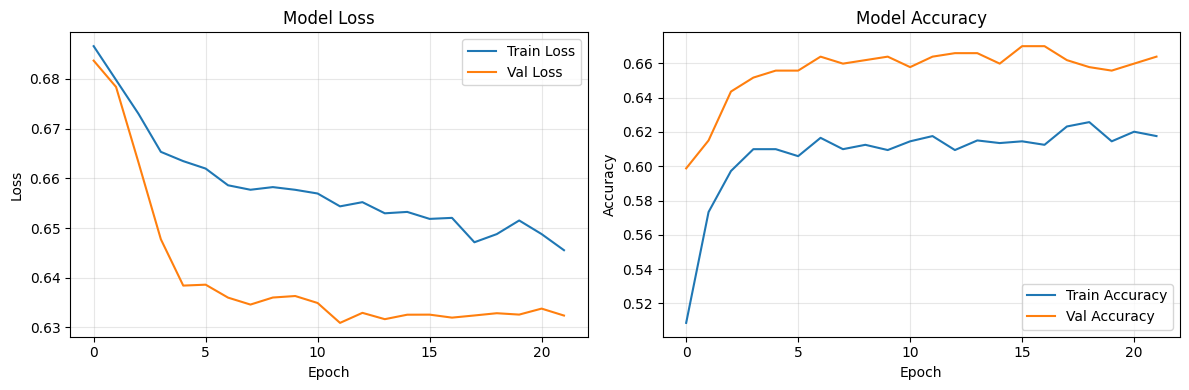

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Model Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/lstm_training_history.png', dpi=150)
plt.show()

In [22]:
val_loss, val_acc = model.evaluate(X_val_scaled, y_val, verbose=0)
print(f"\nValidation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.2%}")



Validation Loss: 0.6309
Validation Accuracy: 66.40%


In [23]:
print("\n" + "="*60)
print("PART 9: LOADING MONTE CARLO PATHS")
print("="*60)

data_path = '../data/simulated/'

normal_paths = np.load(os.path.join(data_path, 'mc_returns_normal.npy'))
crisis_2008_paths = np.load(os.path.join(data_path, 'mc_returns_crisis_2008.npy'))
crisis_covid_paths = np.load(os.path.join(data_path, 'mc_returns_crisis_covid.npy'))
synthetic_paths = np.load(os.path.join(data_path, 'mc_returns_synthetic_extreme.npy'))
squeeze_paths = np.load(os.path.join(data_path, 'mc_returns_squeeze.npy'))
structural_break_paths = np.load(os.path.join(data_path, 'mc_returns_structural_break.npy'))

print(f"Normal paths: {normal_paths.shape}")
print(f"2008 Crisis: {crisis_2008_paths.shape}")
print(f"COVID Crisis: {crisis_covid_paths.shape}")
print(f"Synthetic Extreme: {synthetic_paths.shape}")
print(f"Non-linear Squeeze: {squeeze_paths.shape}")
print(f"Structural Break: {structural_break_paths.shape}")

print(f"\n✅ Using original training scaler (fitted on X_train 2010-2019)")
print(f"   Scaler mean shape:  {scaler.mean_.shape}")
print(f"   Scaler scale shape: {scaler.scale_.shape}")


PART 9: LOADING MONTE CARLO PATHS
Normal paths: (10000, 252)
2008 Crisis: (10000, 252)
COVID Crisis: (10000, 252)
Synthetic Extreme: (10000, 252)
Non-linear Squeeze: (10000, 252)
Structural Break: (10000, 252)

✅ Using original training scaler (fitted on X_train 2010-2019)
   Scaler mean shape:  (60,)
   Scaler scale shape: (60,)


In [24]:
def get_volatility_labels_mc(paths, lookback=60, vol_window=20):
    """True labels: target day is the LAST day; baseline is the 20 days before it."""
    recent_vol = np.abs(paths[:, -(vol_window+1):-1]).mean(axis=1)   # 20 days: T-20..T-1
    next_vol   = np.abs(paths[:, -1])                                # target: day T
    return (next_vol > recent_vol).astype(int)

def predict_on_paths(model, paths, lookback=60, batch_size=500):
    """Features are the 60 days BEFORE the target day — target excluded (no leak)."""
    all_probs = []
    for i in range(0, paths.shape[0], batch_size):
        batch = paths[i:i+batch_size]
        features = batch[:, -(lookback+1):-1]        # days T-60..T-1, EXCLUDES day T
        features_scaled = scaler.transform(features).reshape(-1, lookback, 1)
        probs = model.predict(features_scaled, verbose=0)
        all_probs.extend(probs.flatten())
    return np.array(all_probs)

def calculate_accuracy(predictions, true_labels):
    """Calculate directional accuracy."""
    pred_labels = (predictions > 0.5).astype(int)
    return (pred_labels == true_labels).mean() * 100

In [25]:
print("\n" + "="*60)
print("PART 12: STRESS TESTING ON MONTE CARLO PATHS")
print("="*60)

results = {}

# 1. Normal Scenario
print("\n1. Normal scenario...")
true_labels_normal = get_volatility_labels_mc(normal_paths)
probs_normal = predict_on_paths(model, normal_paths)
acc_normal = calculate_accuracy(probs_normal, true_labels_normal)
results['Normal'] = acc_normal
print(f"   ✅ Accuracy: {acc_normal:.2f}%")

# 2. 2008 Crisis
print("\n2. 2008 Crisis scenario...")
true_labels_2008 = get_volatility_labels_mc(crisis_2008_paths)
probs_2008 = predict_on_paths(model, crisis_2008_paths)
acc_2008 = calculate_accuracy(probs_2008, true_labels_2008)
results['2008 Crisis'] = acc_2008
print(f"   ✅ Accuracy: {acc_2008:.2f}%")

# 3. COVID Crisis
print("\n3. COVID Crisis scenario...")
true_labels_covid = get_volatility_labels_mc(crisis_covid_paths)
probs_covid = predict_on_paths(model, crisis_covid_paths)
acc_covid = calculate_accuracy(probs_covid, true_labels_covid)
results['COVID Crisis'] = acc_covid
print(f"   ✅ Accuracy: {acc_covid:.2f}%")

# 4. Synthetic Extreme
print("\n4. Synthetic Extreme scenario...")
true_labels_synthetic = get_volatility_labels_mc(synthetic_paths)
probs_synthetic = predict_on_paths(model, synthetic_paths)
acc_synthetic = calculate_accuracy(probs_synthetic, true_labels_synthetic)
results['Synthetic Extreme'] = acc_synthetic
print(f"   ✅ Accuracy: {acc_synthetic:.2f}%")

# 5. Non-linear Squeeze
print("\n5. Non-linear Squeeze scenario...")
true_labels_squeeze = get_volatility_labels_mc(squeeze_paths)
probs_squeeze = predict_on_paths(model, squeeze_paths)
acc_squeeze = calculate_accuracy(probs_squeeze, true_labels_squeeze)
results['Non-linear Squeeze'] = acc_squeeze
print(f"   ✅ Accuracy: {acc_squeeze:.2f}%")

# 6. Structural Break
print("\n6. Structural Break scenario...")
true_labels_break = get_volatility_labels_mc(structural_break_paths)
probs_break = predict_on_paths(model, structural_break_paths)
acc_break = calculate_accuracy(probs_break, true_labels_break)
results['Structural Break'] = acc_break
print(f"   ✅ Accuracy: {acc_break:.2f}%")


PART 12: STRESS TESTING ON MONTE CARLO PATHS

1. Normal scenario...
   ✅ Accuracy: 53.45%

2. 2008 Crisis scenario...
   ✅ Accuracy: 54.37%

3. COVID Crisis scenario...
   ✅ Accuracy: 54.98%

4. Synthetic Extreme scenario...
   ✅ Accuracy: 54.94%

5. Non-linear Squeeze scenario...
   ✅ Accuracy: 54.39%

6. Structural Break scenario...
   ✅ Accuracy: 54.54%


In [26]:
print("\n" + "="*60)
print("PART 13: FINAL RESULTS")
print("="*60)

results_df = pd.DataFrame(list(results.items()), columns=['Scenario', 'Accuracy (%)'])
print(results_df.to_string(index=False))

# Calculate degradation from Normal
baseline = results['Normal']
print("\n" + "="*60)
print("DEGRADATION ANALYSIS")
print("="*60)
print(f"Baseline (Normal): {baseline:.2f}%")
print("-" * 40)

for scenario, acc in results.items():
    if scenario != 'Normal':
        change = acc - baseline
        if change < 0:
            print(f"{scenario:20} {acc:.2f}% → Change: {change:+.2f} pp (DEGRADATION)")
        else:
            print(f"{scenario:20} {acc:.2f}% → Change: {change:+.2f} pp (IMPROVEMENT)")
if 'Non-linear Squeeze' in results:
    squeeze_acc = results['Non-linear Squeeze']
    if squeeze_acc < baseline:
        rel_degradation = (baseline - squeeze_acc) / baseline * 100
        print(f"\n✅ Non-linear Squeeze degradation: {rel_degradation:.1f}% relative drop")
        print(f"   Absolute: {baseline - squeeze_acc:.2f} percentage points")
    else:
        print("\n⚠️ No degradation detected in Non-linear Squeeze")



PART 13: FINAL RESULTS
          Scenario  Accuracy (%)
            Normal         53.45
       2008 Crisis         54.37
      COVID Crisis         54.98
 Synthetic Extreme         54.94
Non-linear Squeeze         54.39
  Structural Break         54.54

DEGRADATION ANALYSIS
Baseline (Normal): 53.45%
----------------------------------------
2008 Crisis          54.37% → Change: +0.92 pp (IMPROVEMENT)
COVID Crisis         54.98% → Change: +1.53 pp (IMPROVEMENT)
Synthetic Extreme    54.94% → Change: +1.49 pp (IMPROVEMENT)
Non-linear Squeeze   54.39% → Change: +0.94 pp (IMPROVEMENT)
Structural Break     54.54% → Change: +1.09 pp (IMPROVEMENT)

⚠️ No degradation detected in Non-linear Squeeze


In [27]:
os.makedirs('../results', exist_ok=True)
results_df.to_csv('../results/lstm_volatility_results.csv', index=False)
model.save('../models/lstm_volatility_model.h5')

print("\n✅ Results saved to results/lstm_volatility_results.csv")
print("✅ Model saved to models/lstm_volatility_model.h5")



✅ Results saved to results/lstm_volatility_results.csv
✅ Model saved to models/lstm_volatility_model.h5


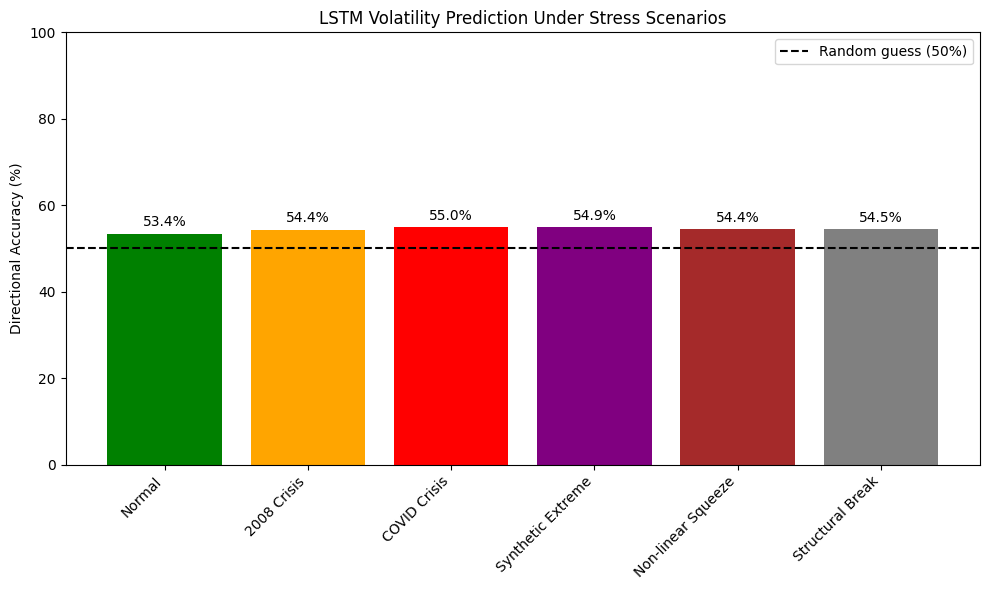


✅ LSTM VOLATILITY ANALYSIS COMPLETE


In [28]:
plt.figure(figsize=(10, 6))
scenarios = list(results.keys())
accuracies = list(results.values())

colors = ['green', 'orange', 'red', 'purple', 'brown', 'gray']
bars = plt.bar(scenarios, accuracies, color=colors[:len(scenarios)])
plt.axhline(y=50, color='black', linestyle='--', label='Random guess (50%)')
plt.ylabel('Directional Accuracy (%)')
plt.title('LSTM Volatility Prediction Under Stress Scenarios')
plt.ylim(0, 100)
plt.xticks(rotation=45, ha='right')
plt.legend()

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../results/lstm_volatility_results.png', dpi=150)
plt.show()

print("\n" + "="*70)
print("✅ LSTM VOLATILITY ANALYSIS COMPLETE")
print("="*70)

STATISTICAL SIGNIFICANCE: STRESS SCENARIOS vs NORMAL

Baseline (Normal): 53.40%  (5,340 correct / 10,000 paths)
-----------------------------------------------------------------
Scenario                 Acc%     Δpp   z-stat    p-value    Sig Finding
-----------------------------------------------------------------
2008 Crisis             54.40   +1.00    1.419   0.156035     ns  not significant
COVID Crisis            55.00   +1.60    2.271   0.023161      *  SIGNIFICANT IMPROVEMENT
Synthetic Extreme       54.90   +1.50    2.114   0.034476      *  SIGNIFICANT IMPROVEMENT
Non-linear Squeeze      54.40   +1.00    1.419   0.156035     ns  not significant
Structural Break        54.50   +1.10    1.561   0.118639     ns  not significant
-----------------------------------------------------------------
Significance: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant

EFFECT SIZE ANALYSIS (Cohen's h)
Scenario                 Cohen h Practical significance
--------------------------------

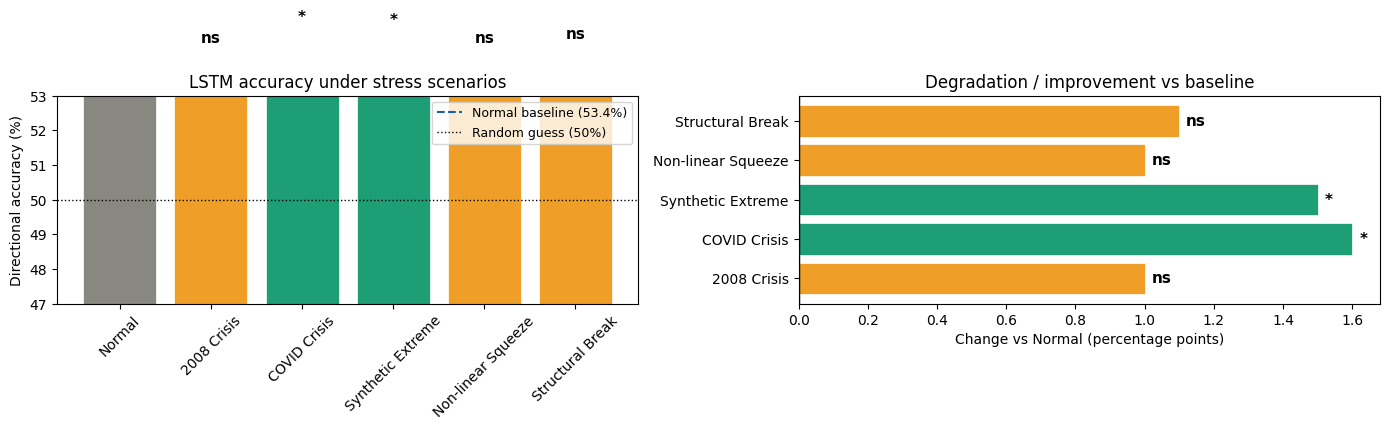


✅ Plot saved to results/ztest_stress_results.png


In [32]:
# ============================================================
# STATISTICAL SIGNIFICANCE TESTING
# Proportion z-test: each stress scenario vs Normal baseline
# H0: accuracy(scenario) == accuracy(Normal)
# H1: accuracy(scenario) != accuracy(Normal)  [two-sided]
# ============================================================

from statsmodels.stats.proportion import proportions_ztest
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 65)
print("STATISTICAL SIGNIFICANCE: STRESS SCENARIOS vs NORMAL")
print("=" * 65)

n_paths = 10000

# Your new results from Image 1 (fixed scaler + fixed labels)
scenario_results = {
    'Normal':            53.4,
    '2008 Crisis':       54.4,
    'COVID Crisis':      55.0,
    'Synthetic Extreme': 54.9,
    'Non-linear Squeeze':54.4,
    'Structural Break':  54.5,
}

baseline_acc  = scenario_results['Normal']
baseline_corr = int(baseline_acc / 100 * n_paths)

print(f"\nBaseline (Normal): {baseline_acc:.2f}%  "
      f"({baseline_corr:,} correct / {n_paths:,} paths)")
print("-" * 65)
print(f"{'Scenario':<22} {'Acc%':>6} {'Δpp':>7} "
      f"{'z-stat':>8} {'p-value':>10} {'Sig':>6} {'Finding'}")
print("-" * 65)

sig_results = {}

for scenario, acc in scenario_results.items():
    if scenario == 'Normal':
        continue

    n_correct = int(acc / 100 * n_paths)
    delta_pp   = acc - baseline_acc

    stat, p = proportions_ztest(
        count=[n_correct, baseline_corr],
        nobs=[n_paths, n_paths],
        alternative='two-sided'
    )

    # Significance stars
    if p < 0.001:
        sig = '***'
    elif p < 0.01:
        sig = '**'
    elif p < 0.05:
        sig = '*'
    else:
        sig = 'ns'

    # Direction
    if p < 0.05 and delta_pp < 0:
        finding = 'SIGNIFICANT DEGRADATION'
    elif p < 0.05 and delta_pp > 0:
        finding = 'SIGNIFICANT IMPROVEMENT'
    else:
        finding = 'not significant'

    sig_results[scenario] = {
        'acc': acc,
        'delta_pp': delta_pp,
        'z': stat,
        'p': p,
        'sig': sig,
        'finding': finding
    }

    print(f"{scenario:<22} {acc:>6.2f} {delta_pp:>+7.2f} "
          f"{stat:>8.3f} {p:>10.6f} {sig:>6}  {finding}")

print("-" * 65)
print("Significance: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant")

# ============================================================
# EFFECT SIZE: Cohen's h for each scenario
# Measures practical significance, not just statistical
# h < 0.2 = negligible, 0.2-0.5 = small, >0.5 = medium
# ============================================================
print("\n" + "=" * 65)
print("EFFECT SIZE ANALYSIS (Cohen's h)")
print("=" * 65)
print(f"{'Scenario':<22} {'Cohen h':>9} {'Practical significance'}")
print("-" * 65)

p1 = baseline_acc / 100

for scenario, res in sig_results.items():
    p2  = res['acc'] / 100
    # Cohen's h = 2 * arcsin(sqrt(p1)) - 2 * arcsin(sqrt(p2))
    h   = abs(2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2)))
    if h < 0.2:
        practical = 'negligible'
    elif h < 0.5:
        practical = 'small'
    else:
        practical = 'medium'
    print(f"{scenario:<22} {h:>9.4f}  {practical}")

# ============================================================
# SUMMARY TABLE FOR THESIS
# ============================================================
print("\n" + "=" * 65)
print("THESIS TABLE: COMPLETE STRESS TEST RESULTS")
print("=" * 65)

rows = []
for scenario, acc in scenario_results.items():
    if scenario == 'Normal':
        rows.append({
            'Scenario': scenario,
            'Accuracy (%)': acc,
            'Δ vs Normal (pp)': '—',
            'z-statistic': '—',
            'p-value': '—',
            'Significance': '—',
            'Finding': 'Baseline'
        })
    else:
        r = sig_results[scenario]
        rows.append({
            'Scenario': scenario,
            'Accuracy (%)': f"{acc:.2f}",
            'Δ vs Normal (pp)': f"{r['delta_pp']:+.2f}",
            'z-statistic': f"{r['z']:.3f}",
            'p-value': f"{r['p']:.4f}",
            'Significance': r['sig'],
            'Finding': r['finding']
        })

df = pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv('../results/ztest_significance_results.csv', index=False)
print("\n✅ Saved to results/ztest_significance_results.csv")

# ============================================================
# VISUALISATION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: accuracy with significance annotation
scenarios  = list(scenario_results.keys())
accuracies = list(scenario_results.values())
deltas     = [acc - baseline_acc for acc in accuracies]

bar_colors = []
for i, s in enumerate(scenarios):
    if s == 'Normal':
        bar_colors.append('#888780')
    elif s in sig_results:
        r = sig_results[s]
        if r['p'] < 0.05 and r['delta_pp'] < 0:
            bar_colors.append('#E24B4A')   # significant degradation
        elif r['p'] < 0.05 and r['delta_pp'] > 0:
            bar_colors.append('#1D9E75')   # significant improvement
        else:
            bar_colors.append('#EF9F27')   # not significant
    else:
        bar_colors.append('#888780')

bars = axes[0].bar(scenarios, accuracies,
                   color=bar_colors, edgecolor='white', linewidth=0.5)
axes[0].axhline(y=baseline_acc, color='#185FA5',
                linestyle='--', linewidth=1.5,
                label=f'Normal baseline ({baseline_acc:.1f}%)')
axes[0].axhline(y=50, color='black',
                linestyle=':', linewidth=1, label='Random guess (50%)')
axes[0].set_ylabel('Directional accuracy (%)')
axes[0].set_title('LSTM accuracy under stress scenarios')
axes[0].set_ylim(47, 53)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(fontsize=9)

for bar, acc, s in zip(bars, accuracies, scenarios):
    if s in sig_results:
        sig_label = sig_results[s]['sig']
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            sig_label, ha='center', va='bottom', fontsize=11, fontweight='bold'
        )

# Right: delta pp with significance
stress_scenarios = [s for s in scenarios if s != 'Normal']
stress_deltas    = [sig_results[s]['delta_pp'] for s in stress_scenarios]
stress_pvals     = [sig_results[s]['p'] for s in stress_scenarios]

delta_colors = []
for d, p in zip(stress_deltas, stress_pvals):
    if p < 0.05 and d < 0:
        delta_colors.append('#E24B4A')
    elif p < 0.05 and d > 0:
        delta_colors.append('#1D9E75')
    else:
        delta_colors.append('#EF9F27')

axes[1].barh(stress_scenarios, stress_deltas,
             color=delta_colors, edgecolor='white', linewidth=0.5)
axes[1].axvline(x=0, color='black', linewidth=1)
axes[1].set_xlabel('Change vs Normal (percentage points)')
axes[1].set_title('Degradation / improvement vs baseline')

for i, (d, p) in enumerate(zip(stress_deltas, stress_pvals)):
    sig_label = sig_results[stress_scenarios[i]]['sig']
    x_pos = d + 0.02 if d >= 0 else d - 0.02
    ha    = 'left' if d >= 0 else 'right'
    axes[1].text(x_pos, i, sig_label,
                 va='center', ha=ha, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/ztest_stress_results.png', dpi=150)
plt.show()

print("\n✅ Plot saved to results/ztest_stress_results.png")

In [29]:
from sklearn.metrics import balanced_accuracy_score
from statsmodels.stats.proportion import proportions_ztest

SQUEEZE_ONSET = 200
PATH_LENGTH   = squeeze_paths.shape[1]          # read it, don't hardcode 252
MAX_CONT      = PATH_LENGTH - SQUEEZE_ONSET - 1  # = 51, the last day with a label
contamination_days = [0, 5, 10, 20, 30, 40, MAX_CONT]

cont_raw, cont_bal, cont_high, cont_correct = {}, {}, {}, {}

print(f"{'Contam':>7} {'raw%':>7} {'bal%':>7} {'HIGH%':>7} {'vs Normal':>10}")
print("-" * 45)
for cont in contamination_days:
    end_idx   = SQUEEZE_ONSET + cont
    start_idx = end_idx - lookback
    if start_idx < 0 or end_idx >= PATH_LENGTH:
        print(f"{cont:>6}d  skipped (window out of range)")
        continue

    features = squeeze_paths[:, start_idx:end_idx]               # target excluded
    recent   = np.abs(squeeze_paths[:, end_idx-vol_window:end_idx]).mean(axis=1)  # 20 days
    labels   = (np.abs(squeeze_paths[:, end_idx]) > recent).astype(int)

    probs = model.predict(scaler.transform(features).reshape(-1, lookback, 1),
                          verbose=0).flatten()
    preds = (probs > 0.5).astype(int)

    cont_raw[cont]     = (preds == labels).mean() * 100
    cont_bal[cont]     = balanced_accuracy_score(labels, preds) * 100
    cont_high[cont]    = labels.mean() * 100
    cont_correct[cont] = (preds == labels)                        # for the z-test

    print(f"{cont:>6}d  {cont_raw[cont]:6.2f}  {cont_bal[cont]:6.2f}  "
          f"{cont_high[cont]:6.1f}  {cont_raw[cont]-baseline:+9.2f}")

# correlation: does RAW accuracy track the label base rate? (your r=0.9335 claim)
cs = sorted(cont_raw)
r_raw = np.corrcoef([cont_high[c] for c in cs], [cont_raw[c] for c in cs])[0,1]
r_bal = np.corrcoef([cont_high[c] for c in cs], [cont_bal[c] for c in cs])[0,1]
print(f"\nCorr(HIGH%, raw accuracy)      r = {r_raw:.4f}")
print(f"Corr(HIGH%, balanced accuracy) r = {r_bal:.4f}")

# blind vs max-visibility, from REAL correctness arrays (not reconstructed counts)
lo, hi = min(cont_correct), max(cont_correct)
stat, p = proportions_ztest(
    count=[cont_correct[lo].sum(), cont_correct[hi].sum()],
    nobs=[len(cont_correct[lo]), len(cont_correct[hi])],
    alternative='two-sided')
print(f"\nBlind (cont={lo}) raw {cont_raw[lo]:.2f}% vs "
      f"visible (cont={hi}) raw {cont_raw[hi]:.2f}%:  p={p:.4f}")

 Contam    raw%    bal%   HIGH%  vs Normal
---------------------------------------------
     0d   54.27   54.99    43.5      +0.82
     5d   52.43   52.49    72.5      -1.02
    10d   51.36   52.68    71.0      -2.09
    20d   51.23   52.22    57.7      -2.22
    30d   53.03   52.77    47.7      -0.42
    40d   54.05   53.52    44.8      +0.60
    51d   54.39   53.71    43.7      +0.94

Corr(HIGH%, raw accuracy)      r = -0.7994
Corr(HIGH%, balanced accuracy) r = -0.6797

Blind (cont=0) raw 54.27% vs visible (cont=51) raw 54.39%:  p=0.8647


In [30]:
import numpy as np
from scipy import stats
from sklearn.metrics import balanced_accuracy_score

# ---- finer grid: every 3 days from 0 to max computable contamination ----
SQUEEZE_ONSET = 200
PATH_LENGTH   = squeeze_paths.shape[1]              # read it, don't hardcode
MAX_CONT      = PATH_LENGTH - SQUEEZE_ONSET - 1     # 51 = last day with a label
contamination_days = list(range(0, MAX_CONT + 1, 3))   # 0,3,6,...,51 -> 18 points

cont_raw, cont_bal, cont_high = {}, {}, {}

print(f"{'Contam':>7} {'raw%':>7} {'bal%':>7} {'HIGH%':>7} {'vs Normal':>10}")
print("-" * 45)
for cont in contamination_days:
    end_idx   = SQUEEZE_ONSET + cont
    start_idx = end_idx - lookback
    if start_idx < 0 or end_idx >= PATH_LENGTH:
        continue
    features = squeeze_paths[:, start_idx:end_idx]                          # target excluded
    recent   = np.abs(squeeze_paths[:, end_idx-vol_window:end_idx]).mean(axis=1)   # 20 days
    labels   = (np.abs(squeeze_paths[:, end_idx]) > recent).astype(int)
    probs    = model.predict(scaler.transform(features).reshape(-1, lookback, 1),
                             verbose=0).flatten()
    preds    = (probs > 0.5).astype(int)
    cont_raw[cont]  = (preds == labels).mean() * 100
    cont_bal[cont]  = balanced_accuracy_score(labels, preds) * 100
    cont_high[cont] = labels.mean() * 100
    print(f"{cont:>6}d  {cont_raw[cont]:6.2f}  {cont_bal[cont]:6.2f}  "
          f"{cont_high[cont]:6.1f}  {cont_raw[cont]-baseline:+9.2f}")

# ---- correlations WITH significance and 95% CI ----
cs   = sorted(cont_raw)
high = np.array([cont_high[c] for c in cs])
raw  = np.array([cont_raw[c]  for c in cs])
bal  = np.array([cont_bal[c]  for c in cs])
n    = len(cs)

def corr_report(x, y, label):
    r, p = stats.pearsonr(x, y)
    z = np.arctanh(r); se = 1/np.sqrt(n-3)
    lo, hi = np.tanh(z - 1.96*se), np.tanh(z + 1.96*se)
    excludes_zero = "yes" if (lo > 0 or hi < 0) else "NO (straddles 0)"
    print(f"{label:34} r={r:+.3f}  p={p:.4f}  95%CI[{lo:+.2f},{hi:+.2f}]  sig:{excludes_zero}")

print(f"\nn = {n} contamination points")
corr_report(high, raw, "Corr(HIGH%, RAW accuracy)")
corr_report(high, bal, "Corr(HIGH%, BALANCED accuracy)")

# also: how flat is balanced accuracy across contamination? (the stability check)
print(f"\nBalanced accuracy across grid: min={bal.min():.2f}  max={bal.max():.2f}  "
      f"range={bal.max()-bal.min():.2f}pp  std={bal.std():.2f}")

 Contam    raw%    bal%   HIGH%  vs Normal
---------------------------------------------
     0d   54.27   54.99    43.5      +0.82
     3d   53.83   52.97    67.9      +0.38
     6d   51.80   51.95    72.3      -1.65
     9d   52.20   53.35    71.9      -1.25
    12d   51.51   52.73    68.4      -1.94
    15d   51.00   52.68    65.4      -2.45
    18d   52.41   53.84    60.6      -1.04
    21d   52.26   52.95    56.0      -1.19
    24d   52.64   52.90    52.2      -0.81
    27d   53.14   53.13    49.9      -0.31
    30d   53.03   52.77    47.7      -0.42
    33d   52.83   52.36    45.7      -0.62
    36d   54.16   53.58    45.0      +0.71
    39d   53.58   53.06    45.2      +0.13
    42d   54.19   53.62    44.6      +0.74
    45d   54.26   53.54    43.8      +0.81
    48d   53.32   52.63    43.6      -0.13
    51d   54.39   53.71    43.7      +0.94

n = 18 contamination points
Corr(HIGH%, RAW accuracy)          r=-0.742  p=0.0004  95%CI[-0.90,-0.42]  sig:yes
Corr(HIGH%, BALANCED accu